In [31]:
import pandas as pd
import numpy as np
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [2]:
print(train.head())
print(train.info())
print(train.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

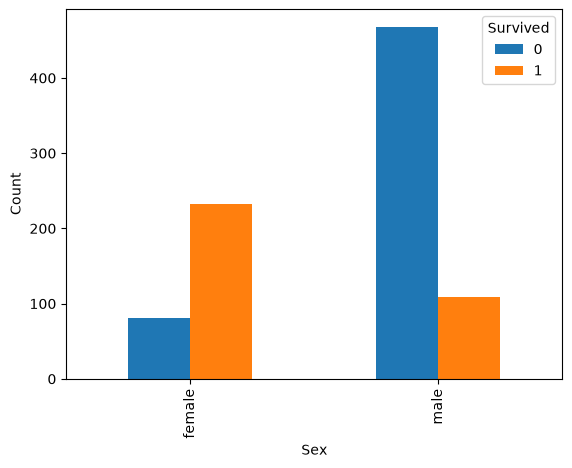

In [4]:
import matplotlib.pyplot as plt

pd.crosstab(train["Sex"], train["Survived"]).plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

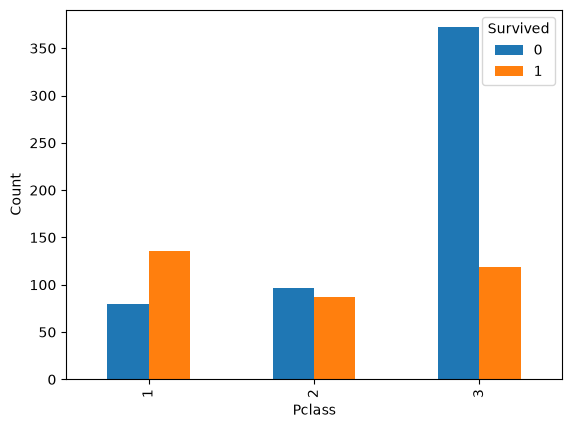

In [5]:
pd.crosstab(train["Pclass"], train["Survived"]).plot(kind="bar")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

In [6]:
print(pd.crosstab(
    train["Pclass"],
    train["Survived"],
    normalize="index"
))

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363


In [7]:
train.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [8]:
train.groupby("Survived")["Age"].median()

Survived
0    28.0
1    28.0
Name: Age, dtype: float64

In [32]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

print(pd.crosstab(
    train["FamilySize"],
    train["Survived"],
    normalize="index"
))

Survived           0         1
FamilySize                    
1           0.696462  0.303538
2           0.447205  0.552795
3           0.421569  0.578431
4           0.275862  0.724138
5           0.800000  0.200000
6           0.863636  0.136364
7           0.666667  0.333333
8           1.000000  0.000000
11          1.000000  0.000000


In [33]:
print(train.groupby("Survived")
["Fare"].median())

Survived
0    10.5
1    26.0
Name: Fare, dtype: float64


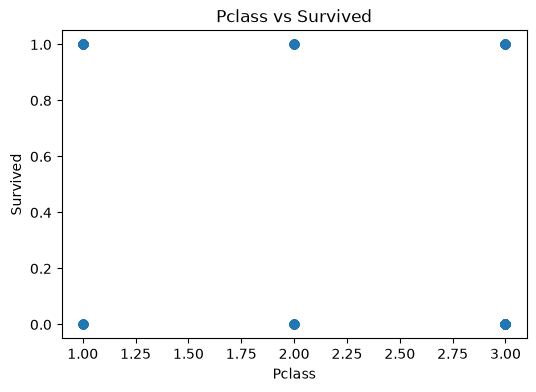

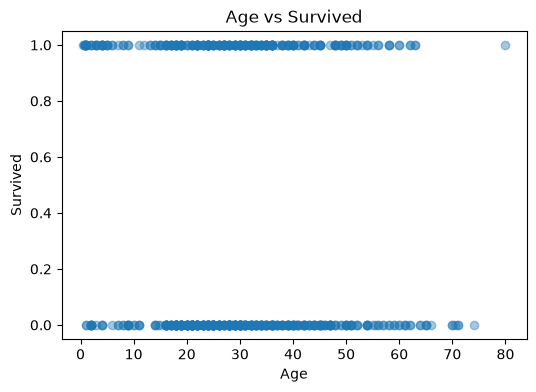

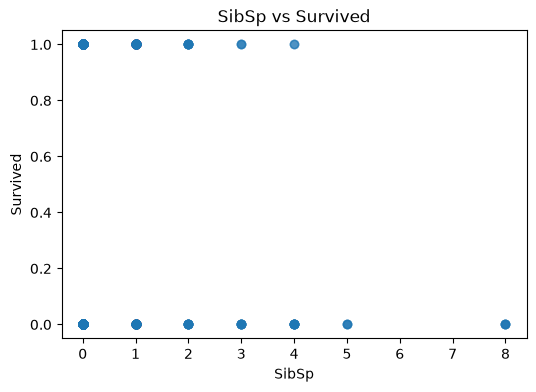

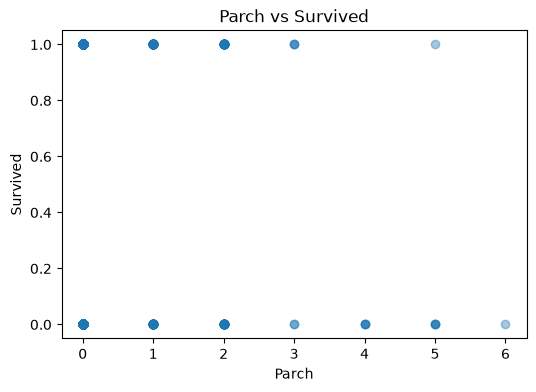

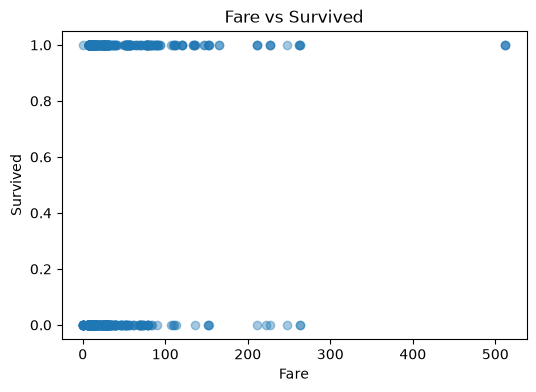

In [34]:
import matplotlib.pyplot as plt

features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(train[feature], train["Survived"], alpha=0.4)
    plt.xlabel(feature)
    plt.ylabel("Survived")
    plt.title(f"{feature} vs Survived")
    plt.show()

In [35]:
for df in [train, test]:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")

    common_titles = ["Mr", "Miss", "Mrs", "Master"]
    df["Title"] = df["Title"].where(
        df["Title"].isin(common_titles),
        "Rare"
    )

In [36]:
drop_cols = ["PassengerId", "Name", "Ticket", "Cabin"]

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

In [37]:
x = train.drop("Survived", axis=1)
y = train["Survived"]

In [38]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    stratify=y
)

In [39]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

categorical_features = [
    "Sex",
    "Embarked",
    "Title"
]

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(x_train, y_train)

y_pred = logistic_model.predict(X_val)

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8491620111731844


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       110
           1       0.83      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



In [46]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf"))
])

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(X_val)

In [47]:
print("Accuracy:", accuracy_score(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))

Accuracy: 0.8435754189944135
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       110
           1       0.83      0.75      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(X_val)

In [50]:
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Accuracy: 0.9497206703910615
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       110
           1       0.95      0.91      0.93        69

    accuracy                           0.95       179
   macro avg       0.95      0.94      0.95       179
weighted avg       0.95      0.95      0.95       179



In [52]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(X_val)

In [53]:
print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print(classification_report(y_val, y_pred_knn))

Accuracy: 0.8603351955307262
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       110
           1       0.83      0.80      0.81        69

    accuracy                           0.86       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.86      0.86      0.86       179



[[107   3]
 [  6  63]]


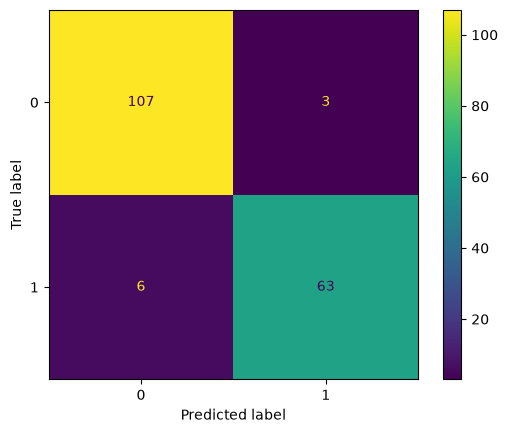

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred_rf)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


In [55]:
rf_model.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Pclass','Sex','Age',...,'FamilySize','IsAlone','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

In [57]:
test_pred = rf_model.predict(test)

In [63]:
answer = pd.read_csv("gender_submission.csv")

In [64]:
result = submission.merge(
    answer,
    on="PassengerId",
    suffixes=("_pred", "_true")
)

In [65]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    result["Survived_true"],
    result["Survived_pred"]
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.8205741626794258
